## Neural Network

#### =============================================================
#### Part 1: Neural Network for Classification Problem
#### Dataset: Handwritten_Data.mat
#### =============================================================

In this part, you will use neural network to recognize handwritten digits (from 0 to 9). Automated handwritten digit recognition is widely used today - from recognizing zip codes (postal codes) on mail envelopes to recognizing amounts written on bank checks. This exercise will show you how the neural network you have learned can be used for this classification task.

You are given a data set that contains 5000 training examples of handwritten digits (This is a subset of the MNIST handwritten digit dataset). The .mat format means that the data has been saved in a native Octave/MATLAB matrix format, instead of a text (ASCII) format like a csv-file. Fortunately, python provides mechanisms to load MATLAB native format using the loadmat function within the scipy.io module. This function returns a python dictionary with keys containing the variable names within the .mat file.

There are 5000 training examples in HandWritten_Data.mat, where each training example is a 20 pixel by 20 pixel grayscale image of the digit. Each pixel is represented by a floating point number indicating the grayscale intensity at that location. The 20 by 20 grid of pixels is “unrolled” into a 400-dimensional vector. Each of these training examples becomes a single row in our data matrix X. This gives us a 5000 by 400 matrix X where every row is a training example for a handwritten digit image. The second part of the training set is a 5000-dimensional vector y that contains labels for the training set.

Ref: Machine Learning by Andrew Ng: www.coursera.org/

In [55]:
# ==============================
# Step 1: Import libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.neural_network import MLPClassifier   # for classification problem
from sklearn.neural_network import MLPRegressor    # for regression problem
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [56]:
# Mount file
# from google.colab import drive
# drive.mount('/content/drive')

In [57]:
# ==============================
# Step 2: Load Handwritten Data
# ==============================

data = loadmat('/content/drive/MyDrive/Lecture Note/Year 4/Semester 2/INTRO MAC LANG IE/Python Code/05_NN/Data/HandWritten_Data.mat')

X = data['X']          # shape (5000, 400)
y = data['y']          # shape (5000, 1)

# Matlab labels: 1..10 (where 10 means digit 0)
y[y == 10] = 0
y = y.ravel()

# .ravel() flattens a column vector into a 1-D array
# scikit-learn expects target vectors (y) to be 1D arrays (m,), not column vectors (m, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 400)
y shape: (5000,)


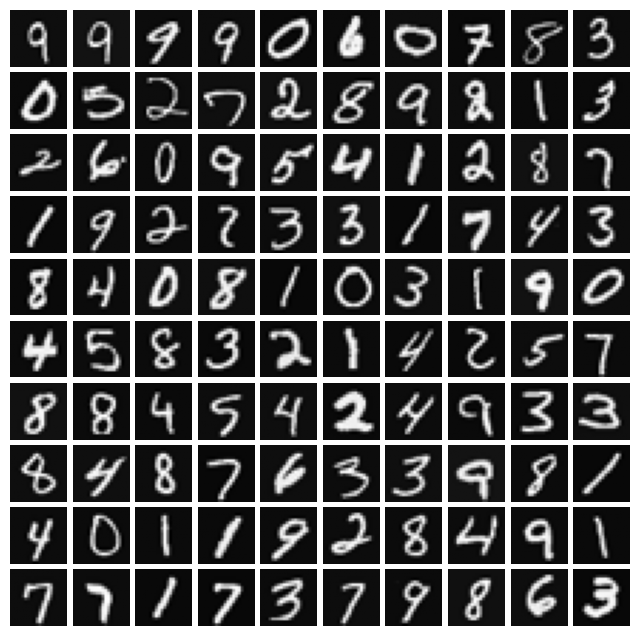

In [58]:
# ==============================
# Step 3: Visualize random digits
# ==============================

def display_digits(X, example_width = None):
    m, n = X.shape

    # If example_width is not given, assume the image is square
    # Since each image has n pixels (400), sqrt(400) = 20 → width = 20
    example_width = example_width or int(np.sqrt(n))

    # Image height is computed from total pixels divided by width
    # 400 pixels / 20 width = 20 height
    example_height = n // example_width

    display_rows = 10
    display_cols = 10

    fig, axes = plt.subplots(display_rows, display_cols, figsize = (8,8))
    fig.subplots_adjust(wspace = 0.1, hspace = 0.1)
    # Reduce spacing between subplots so the 100 images form a tight grid
    # wspace = horizontal spacing between images
    # hspace = vertical spacing between images

    for ax in axes.flat:    # axes.flat lets us iterate through all 100 subplot locations
        # Randomly pick one example from the dataset
        idx = np.random.randint(0, m)
        ax.imshow(X[idx].reshape(example_height, example_width).T, cmap = 'gray')
        ax.axis('off')     # Removes axis ticks and borders


display_digits(X)
plt.show()

In [59]:
# Show the possible values of y
print(np.unique(data['y']))

[0 1 2 3 4 5 6 7 8 9]


Train Model

For your information
- [Step 4 NN - 1 Layers](https://github.com/SKY-TKP/Machine-Learning-for-IE/blob/main/2104-305%3A%20INTRO%20MAC%20LANG%20IE/Coding%20Tutorial/L5%3A%20Neural%20Network/Data/NN_Step4.png)
- [Step 4.1 NN - 2 Hidden Layers](https://github.com/SKY-TKP/Machine-Learning-for-IE/blob/main/2104-305%3A%20INTRO%20MAC%20LANG%20IE/Coding%20Tutorial/L5%3A%20Neural%20Network/Data/NN_Step4.1.jpg)

In [60]:
# ==============================
# Step 4: One Hidden Layer
# ==============================

model_1layer = MLPClassifier(        # create a Neural Network classifier (Multi-Layer Perceptron)
    hidden_layer_sizes = (25,),      # tuple indicates the number of hidden layers and units: 1 layer and 25 neurons in that layer
    activation = 'logistic',         # Use sigmoid activation function
    solver = 'lbfgs',                # optimization algorithm used to minimize the cost function J
    max_iter = 300,                  # maximum number of iterations for the optimizer
    random_state = 42
)

model_1layer.fit(X, y)
y_pred_1 = model_1layer.predict(X)   # MLP produces 10 output neurons and chooses the class with the highest probability

print("Accuracy (one hidden layer):",
      accuracy_score(y, y_pred_1))

Accuracy (one hidden layer): 1.0


In [61]:
# ==============================
# Step 4.1: Two Hidden Layers
# ==============================

model_2layer = MLPClassifier(
    hidden_layer_sizes = (25, 25),    # 2 layers and 25 neurons in each layer
    activation = 'logistic',
    solver = 'lbfgs',
    max_iter = 300,
    random_state = 42
)

model_2layer.fit(X, y)
y_pred_2 = model_2layer.predict(X)

print("Accuracy (two hidden layers):",
      accuracy_score(y, y_pred_2))

Accuracy (two hidden layers): 0.9998


In [62]:
# ==============================
# Step 5: Evaluate both models
# ==============================

# --- Accuracy ---
print("Accuracy (1 hidden layer):",
      accuracy_score(y, y_pred_1))

print("Accuracy (2 hidden layers):",
      accuracy_score(y, y_pred_2))


# --- Classification report ---
print("\nClassification Report (one hidden layer):")
print(classification_report(y, y_pred_1, digits = 4))

print("\nClassification Report (two hidden layers):")
print(classification_report(y, y_pred_2, digits = 4))

Accuracy (1 hidden layer): 1.0
Accuracy (2 hidden layers): 0.9998

Classification Report (one hidden layer):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       500
           1     1.0000    1.0000    1.0000       500
           2     1.0000    1.0000    1.0000       500
           3     1.0000    1.0000    1.0000       500
           4     1.0000    1.0000    1.0000       500
           5     1.0000    1.0000    1.0000       500
           6     1.0000    1.0000    1.0000       500
           7     1.0000    1.0000    1.0000       500
           8     1.0000    1.0000    1.0000       500
           9     1.0000    1.0000    1.0000       500

    accuracy                         1.0000      5000
   macro avg     1.0000    1.0000    1.0000      5000
weighted avg     1.0000    1.0000    1.0000      5000


Classification Report (two hidden layers):
              precision    recall  f1-score   support

           0     1.0000    1.0000

In [63]:
# --- Show probability vector for one example ---
np.set_printoptions(suppress = True, precision = 6)
# suppress = True → disables scientific notation
# precision = 10 → show 10 decimal places

In [64]:
# Predicted probability for each class
sample_index = 0

print("\nProbability output h_theta(x) for sample 0 (one hidden layer):")
print(model_1layer.predict_proba(X)[sample_index])
print('Predicted class for sample 0 (one hidden layer):', y_pred_1[0])

print("\nProbability output h_theta(x) for sample 0 (two hidden layers):")
print(model_2layer.predict_proba(X)[sample_index])
print('Predicted class for sample 0 (two hidden layers):', y_pred_2[0])


Probability output h_theta(x) for sample 0 (one hidden layer):
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted class for sample 0 (one hidden layer): 0

Probability output h_theta(x) for sample 0 (two hidden layers):
[0.99992 0.      0.      0.      0.      0.      0.      0.      0.
 0.00008]
Predicted class for sample 0 (two hidden layers): 0


In [65]:
# ==============================
# Step 6: Cost Function J (Theta) for one hidden layer
# ==============================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def nn_cost_function(Theta1, Theta2, X, y, lambda_):
    m = X.shape[0]

    # Number of output units (number of classes)
    num_labels = Theta2.shape[0]

    # One-hot encode y
    # Convert class labels (0–9) into one-hot encoded vectors.
    # Example: y = 3  →  [0 0 0 1 0 0 0 0 0 0]
    # This is required for computing the neural network cost function with multiple output units.
    Y = np.eye(num_labels)[y]             # dimension of Y is m x num_labels

    # Forward propagation
    a1 = np.c_[np.ones(m), X]             # add the bias unit to a1

    # Hidden layer
    z2 = np.dot(a1, Theta1.T)             # compute z2
    a2 = np.c_[np.ones(m), sigmoid(z2)]   # add the bias unit to a2

    # Output Layer
    z3 = np.dot(a2, Theta2.T)             # compute z3
    h = sigmoid(z3)                       # compute final output (hypothesis)

    # Prevent log(0) numerical issue
    h = np.clip(h, 1e-15, 1 - 1e-15)

    # Cost
    term1 = -Y * np.log(h)
    term2 = (1 - Y) * np.log(1 - h)
    J = np.sum(term1 - term2) / m

    # Regularization
    reg = (lambda_ / (2*m)) * (
        np.sum(np.square(Theta1[:,1:])) +
        np.sum(np.square(Theta2[:,1:]))
    )

    return J + reg

In [66]:
# ==============================
# Step 6.1: Cost Function J(Theta) for two hidden layers
# ==============================

def nn_cost_function_2layers(Theta1, Theta2, Theta3, X, y, lambda_):
    m = X.shape[0]

    # Number of output units (number of classes)
    num_labels = Theta3.shape[0]

    # One-hot encode y (same as before)
    Y = np.eye(num_labels)[y]

    # ---------- Forward Propagation ----------

    # Input layer
    a1 = np.c_[np.ones(m), X]              # add the bias unit to a1

    # Hidden layer 1
    z2 = np.dot(a1, Theta1.T)              # compute z2
    a2 = np.c_[np.ones(m), sigmoid(z2)]    # add the bias unit to a2

    # Hidden layer 2
    z3 = np.dot(a2, Theta2.T)              # compute z3
    a3 = np.c_[np.ones(m), sigmoid(z3)]    # add the bias unit to a3

    # Output layer
    z4 = np.dot(a3, Theta3.T)              # compute z4
    h = sigmoid(z4)                        # compute final output (hypothesis)

    # Prevent log(0) numerical issue
    h = np.clip(h, 1e-15, 1 - 1e-15)

    # ---------- Cost Function ----------

    term1 = -Y * np.log(h)
    term2 = (1 - Y) * np.log(1 - h)
    J = np.sum(term1 - term2) / m

    # ---------- Regularization ----------
    reg = (lambda_ / (2*m)) * (
        np.sum(np.square(Theta1[:,1:])) +
        np.sum(np.square(Theta2[:,1:])) +
        np.sum(np.square(Theta3[:,1:]))
    )

    return J + reg

In [67]:
# ==============================
# Step 7: Build Theta matrices from trained sklearn models
# ==============================

def build_theta(W, b):
    """
    Combine sklearn weight matrix W and bias vector b
    into the Theta format expected by the lecture cost function.

    sklearn:
        W shape = (n_in, n_out)
        b shape = (n_out,)

    Lecture Theta:
        shape = (n_out, n_in + 1)
    """
    return np.c_[b, W.T]

In [68]:
# ==============================
# Step 8: Compare costs (1 hidden layer)
# ==============================

# Build Theta matrices from trained model
Theta1_trained_1 = build_theta(
    model_1layer.coefs_[0],
    model_1layer.intercepts_[0]
)

Theta2_trained_1 = build_theta(
    model_1layer.coefs_[1],
    model_1layer.intercepts_[1]
)

# Lecture cost J(Theta)
J_lecture_1layer = nn_cost_function(
    Theta1_trained_1,
    Theta2_trained_1,
    X, y, lambda_ = 1
)

# scikit-learn cost (softmax cross-entropy)
J_sklearn_1layer = model_1layer.loss_

print("=== One Hidden Layer ===")
print("Lecture Cost J(Theta):      ", J_lecture_1layer)
print("scikit-learn Loss:          ", J_sklearn_1layer)

=== One Hidden Layer ===
Lecture Cost J(Theta):       18.781965397038167
scikit-learn Loss:           0.002174240866456214


In [69]:
# ==============================
# Step 9: Compare costs (2 hidden layers)
# ==============================

Theta1_trained_2 = build_theta(
    model_2layer.coefs_[0],
    model_2layer.intercepts_[0]
)

Theta2_trained_2 = build_theta(
    model_2layer.coefs_[1],
    model_2layer.intercepts_[1]
)

Theta3_trained_2 = build_theta(
    model_2layer.coefs_[2],
    model_2layer.intercepts_[2]
)

# Lecture cost J(Theta)
J_lecture_2layer = nn_cost_function_2layers(
    Theta1_trained_2,
    Theta2_trained_2,
    Theta3_trained_2,
    X, y, lambda_ = 1
)

# scikit-learn cost (softmax cross-entropy)
J_sklearn_2layer = model_2layer.loss_

print("\n=== Two Hidden Layers ===")
print("Lecture Cost J(Theta):      ", J_lecture_2layer)
print("scikit-learn Loss:          ", J_sklearn_2layer)


=== Two Hidden Layers ===
Lecture Cost J(Theta):       19.04932811592953
scikit-learn Loss:           0.001638607512222446


In [70]:
# =============================================================
# WHY THE TWO COST VALUES ARE VERY DIFFERENT
# =============================================================
# The Theta parameters used here are the OPTIMAL parameters
# learned by scikit-learn's MLPClassifier.
#
# These parameters produce the same final linear outputs (z)
# in both cases:
#
#   For 1 hidden layer:  z3 = np.dot(a2, Theta2.T)    [from Step 6]
#   For 2 hidden layers: z4 = np.dot(a3, Theta3.T)    [from Step 6.1]
#
# This z is the last linear result before applying an activation
# function at the output layer. In machine learning, this is
# often called the "logits".
#
# -------------------------------------------------------------
# The important point:
# The z values are the SAME, but the activation function applied
# to z is DIFFERENT in the lecture formulation and in sklearn.
# -------------------------------------------------------------
#
# Lecture formulation:
#   h_k = sigmoid(z_k)
#   - Each output unit is independent
#   - The cost treats this as K separate logistic regressions
#
# scikit-learn formulation:
#   p_k = softmax(z_k)
#   - The K outputs are connected through softmax
#   - All probabilities must sum to 1 (they compete)
#
# Because of this difference:
#
# - Softmax forces one class to be very close to 1
#   and all other classes very close to 0.
#
# - When we apply sigmoid to the same z values,
#   we get small but non-zero values for all other classes.
#
# The lecture cost interprets these as 9 separate
# "negative examples" and penalizes them repeatedly,
# which causes the lecture cost J(Theta) to be very large.
#
# However, under softmax cross-entropy (sklearn loss),
# these small probabilities are correct and desirable.
#
# -------------------------------------------------------------
# KEY LESSON:
# The same network parameters can be optimal for one cost
# function and appear very poor under another cost function.
# This is because the definition of the cost function determines
# what "optimal" means.
# =============================================================

In [71]:
# =============================================================
# WHY GRADIENT CHECKING IS NOT REQUIRED HERE
# =============================================================
# Gradient checking is needed only when we implement
# backpropagation ourselves to verify correctness.
#
# In this notebook, we use scikit-learn's MLPClassifier.
# The gradients and backpropagation inside this library
# have already been tested and verified by the developers.
#
# Our purpose here is not to implement backpropagation,
# but to compare two different cost definitions using
# the same learned parameters.
# =============================================================

#### =============================================================
#### Part 2: Neural Network for Regression Problem
#### Dataset: HousePrice_Data.csv
#### =============================================================

This dataset contains 21 columns and 21613 rows. The dataset range is from May 2014 to May 2015.
Columns are as follows:
- id: A notation for a house
- date: date when the house was sold
- price: price is prediction target
- bedrooms: Number of bedrooms
- bathrooms: Number of bathrooms
- sqft_living : Square footage of the home
- sqft_lot: Square footage of the lot
- floors: Total floors (levels) in the house
- waterfront: House which has a view to the waterfront
- view: Has been viewed
- condition: how good is the overall condition of the house
- grade: overall grade given to the housing unit, based on King County Grading System
- sqft_above: Square footage of the house apart from basement
- sqft_basement: Square footage of the basement
- yr_built: year the house was built
- yr_renovated: year the house was renovated
- zipcode: zipcode of the house
- lat: Latitude coordinate
- long: Longitude coordinate
- sqft_living15: Living room area in 2015 (implies some renovation)
- sqft_lot15: Lot size area in 2015 (implies some renovation)

Ref: Kaggle Dataset https://www.kaggle.com/datasets/vikramamin/kc-house-dataset-home-prices

In [72]:
# ==============================
# Step 1: Load dataset
# ==============================

df = pd.read_csv("https://raw.githubusercontent.com/SKY-TKP/Machine-Learning-for-IE/refs/heads/main/2104-305%3A%20INTRO%20MAC%20LANG%20IE/Coding%20Tutorial/L5%3A%20Neural%20Network/Data/HousePrice_Data.csv")
print(df.shape)
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  int64  
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [75]:
# ==============================
# Step 2: Preprocess Data
# ==============================

# Step 2.1: Drop irrelevant features

df = df.drop(columns=['id', 'date', 'lat', 'long'])

In [76]:
# Plot Correlation Matrix
df.corr().style.background_gradient(cmap='coolwarm')

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15
price,1.000000,0.308338,0.475317,0.702044,0.089655,0.256786,0.266331,0.397346,0.036392,0.667463,0.605565,0.323837,0.053982,0.126442,-0.053168,0.585374,0.082456
bedrooms,0.308338,1.000000,0.492322,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477616,0.303093,0.154178,0.018841,-0.152668,0.391638,0.029244
bathrooms,0.475317,0.492322,1.000000,0.719901,0.077230,0.509377,0.054418,0.165726,-0.143021,0.645621,0.671063,0.238396,0.530225,0.035621,-0.212194,0.555900,0.077937
sqft_living,0.702044,0.576671,0.719901,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876644,0.435043,0.318049,0.055363,-0.199430,0.756420,0.183286
sqft_lot,0.089655,0.031703,0.077230,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183511,0.015286,0.053080,0.007644,-0.129574,0.144608,0.718557
floors,0.256786,0.175429,0.509377,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523899,-0.245705,0.489319,0.006338,-0.059121,0.279885,-0.011269
waterfront,0.266331,-0.006582,0.054418,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072074,0.080588,-0.026161,0.092885,0.030285,0.086463,0.030703
view,0.397346,0.079532,0.165726,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167648,0.276947,-0.053440,0.103917,0.084827,0.280439,0.072575
condition,0.036392,0.028472,-0.143021,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158206,0.174105,-0.361417,-0.060618,0.003026,-0.092824,-0.003406
grade,0.667463,0.356967,0.645621,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755924,0.168392,0.446963,0.014414,-0.184862,0.713202,0.119248


In [78]:
# Step 2.2: Separate target variable

y = df['price']
X = df.drop(columns=['price'])

# Step 2.3: Remove redundant features

X = X.drop(columns=['sqft_above', 'sqft_basement'])

# Step 2.4: One-hot encode zipcode

X = pd.get_dummies(X, columns=['zipcode'], drop_first=True)

# Step 2.5: Train / Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print(X_train.shape, X_test.shape)

# Step 2.7: Feature scaling

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

# Step 2.8: Log-transform target variable

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# We use log(price) because house prices are highly skewed
# (a few very expensive houses create a long right tail).
# Neural networks learn better when the target has a smaller,
# more symmetric range. The log transform reduces skewness,
# stabilizes gradients, and makes optimization easier.

(17290, 82) (4323, 82)


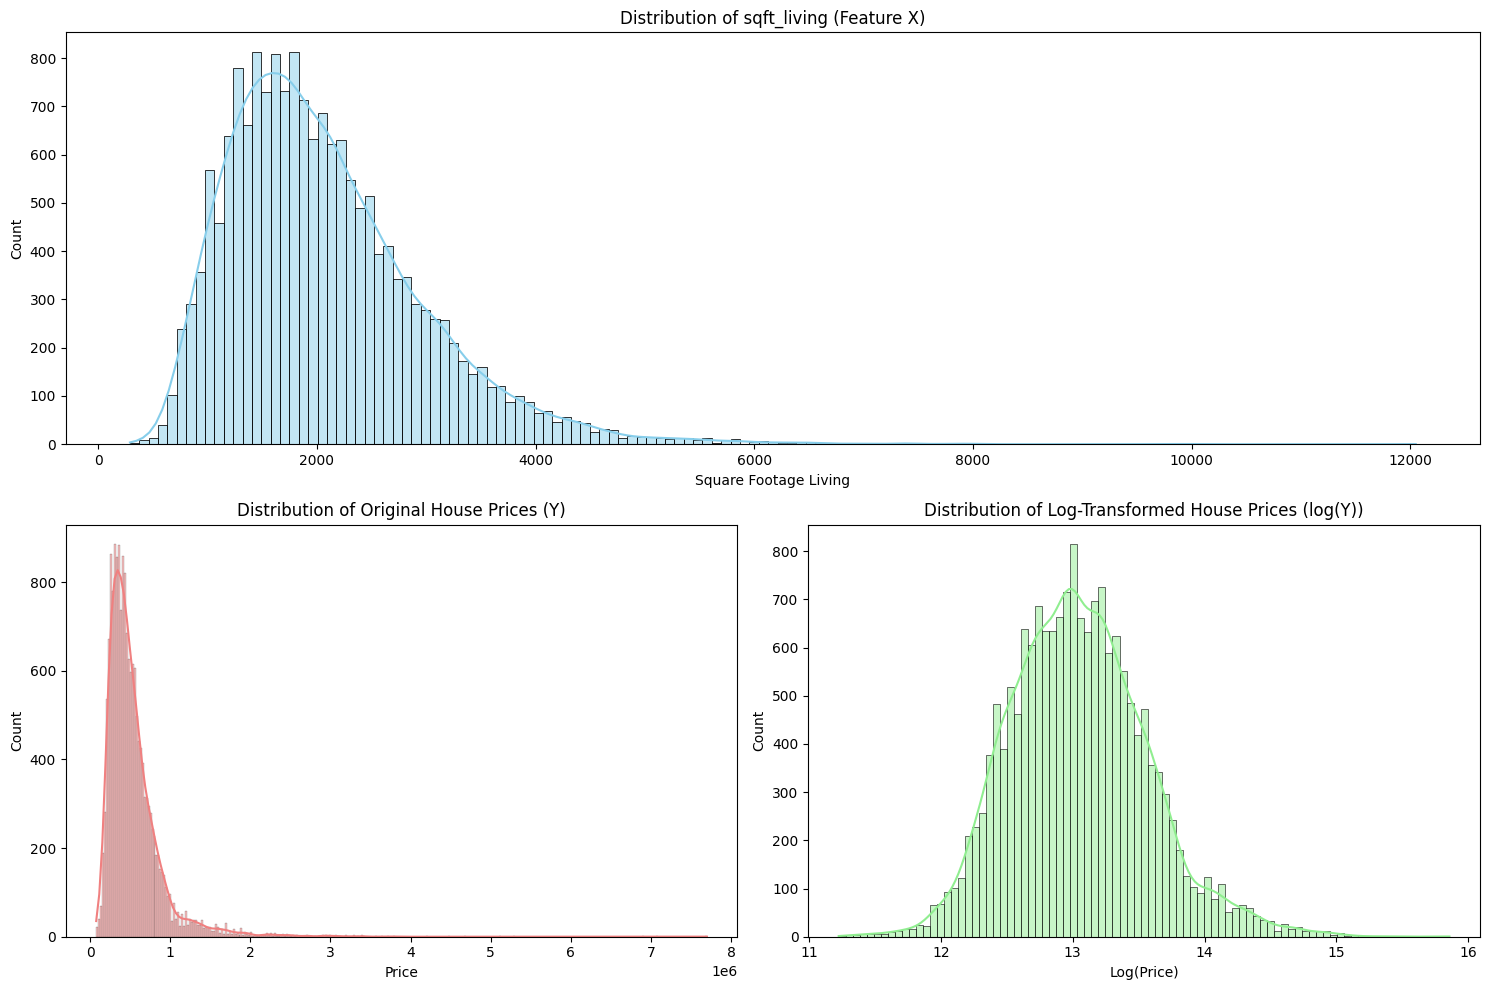

In [79]:
import seaborn as sns

# Create a figure and a grid of subplots
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2) # 2 rows, 2 columns grid

# Plot histogram for a representative X feature (e.g., sqft_living from X_train)
# This plot will span both columns in the first row
ax1 = fig.add_subplot(gs[0, :])
sns.histplot(X_train['sqft_living'], kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of sqft_living (Feature X)')
ax1.set_xlabel('Square Footage Living')
ax1.set_ylabel('Count')

# Plot histogram for original y (y_train)
# This plot will be in the first column of the second row
ax2 = fig.add_subplot(gs[1, 0])
sns.histplot(y_train, kde=True, ax=ax2, color='lightcoral')
ax2.set_title('Distribution of Original House Prices (Y)')
ax2.set_xlabel('Price')
ax2.set_ylabel('Count')

# Plot histogram for log-transformed y (y_train_log)
# This plot will be in the second column of the second row
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(y_train_log, kde=True, ax=ax3, color='lightgreen')
ax3.set_title('Distribution of Log-Transformed House Prices (log(Y))')
ax3.set_xlabel('Log(Price)')
ax3.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [80]:
# ==============================
# Step 3: Neural Network with one hidden layer
# ==============================

model_1layer_reg = MLPRegressor(
    hidden_layer_sizes = (50,),    # 1 layer with 50 neurons
    activation = 'relu',
    solver = 'adam',
    max_iter = 500,
    random_state = 42
)

# activation = 'relu':
#   Uses ReLU function in hidden layers: f(z) = max(0, z)
#   Helps faster learning and avoids vanishing gradient problem.

# In MLPRegressor, the output layer is linear (no activation).

# solver = 'adam':
#   Optimization algorithm that updates weights using adaptive learning rates.
#   Works well for large datasets and requires little tuning.
#   This solver performs backpropagation + weight updates internally.

model_1layer_reg.fit(X_train_scaled, y_train_log)
y_pred_log_1 = model_1layer_reg.predict(X_test_scaled)

# Convert predictions back to original price
y_pred_1layer = np.exp(y_pred_log_1)

In [81]:
# ==============================
# Step 3.1: Neural Network with two hidden layers
# ==============================

model_2layer_reg = MLPRegressor(
    hidden_layer_sizes = (50, 50),    # 2 layers and 50 neurons in each layer
    activation = 'relu',
    solver = 'adam',
    max_iter = 500,
    random_state = 42
)

model_2layer_reg.fit(X_train_scaled, y_train_log)
y_pred_log_2 = model_2layer_reg.predict(X_test_scaled)

# Convert predictions back to original price
y_pred_2layer = np.exp(y_pred_log_2)

In [82]:
# ==============================
# Step 4: Evaluate models
# ==============================

print("=== Evaluation in log(price) space ===")

mse_1 = mean_squared_error(y_test_log, y_pred_log_1)
r2_1 = r2_score(y_test_log, y_pred_log_1)

mse_2 = mean_squared_error(y_test_log, y_pred_log_2)
r2_2 = r2_score(y_test_log, y_pred_log_2)

# Since the model predicts log(price), evaluation must also
# be done in log space.

print("=== One Hidden Layer ===")
print("MSE:", mse_1)
print("R^2:", r2_1)

print("\n=== Two Hidden Layers ===")
print("MSE:", mse_2)
print("R^2:", r2_2)

=== Evaluation in log(price) space ===
=== One Hidden Layer ===
MSE: 0.04435824007217278
R^2: 0.8444606850488833

=== Two Hidden Layers ===
MSE: 0.041907675632912554
R^2: 0.8530534315939658


In [83]:
# ==============================
# Step 5: Training loss (sklearn regression loss)
# ==============================

print("Final training loss (1 layer):", model_1layer_reg.loss_)
print("Final training loss (2 layers):", model_2layer_reg.loss_)

Final training loss (1 layer): 0.014864247056596454
Final training loss (2 layers): 0.016505851784930806


## Activated Function

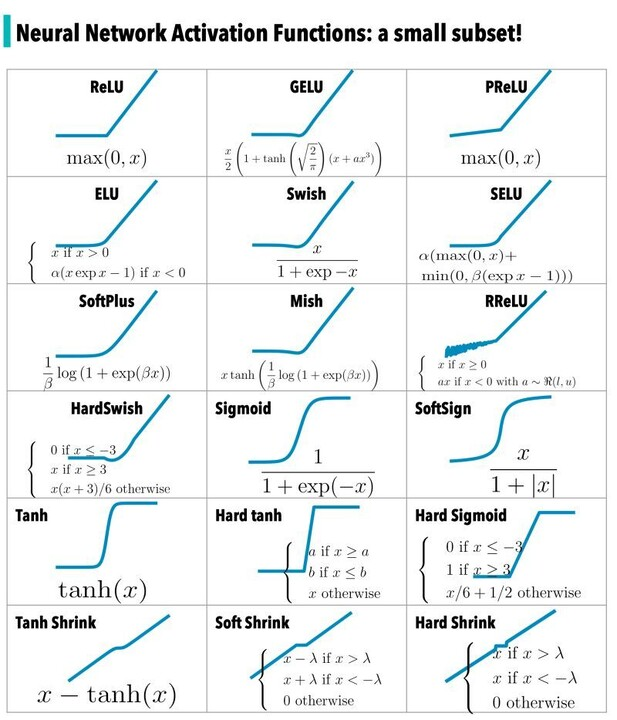

### ReLU

$$f(z) = max(0, z) = z 𝕀(z > 0)$$

Text(0, 0.5, 'ReLU(x)')

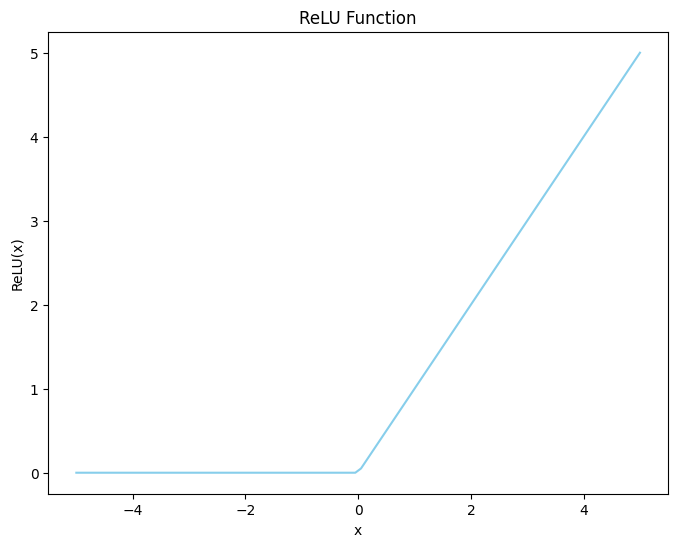

In [84]:
# Plot the ReLU function
x = np.linspace(-5, 5, 100)
relu_values = [i * (i > 0) for i in x] # ReLU Function

plt.figure(figsize=(8, 6))
plt.plot(x, relu_values, label='ReLU', color='skyblue')
plt.title('ReLU Function')
plt.xlabel('x')
plt.ylabel('ReLU(x)')

### Leaky ReLU

$$f(z) = max(cz, z)$$

Where $c$ is constant.

Text(0, 0.5, 'Leaky ReLU(x)')

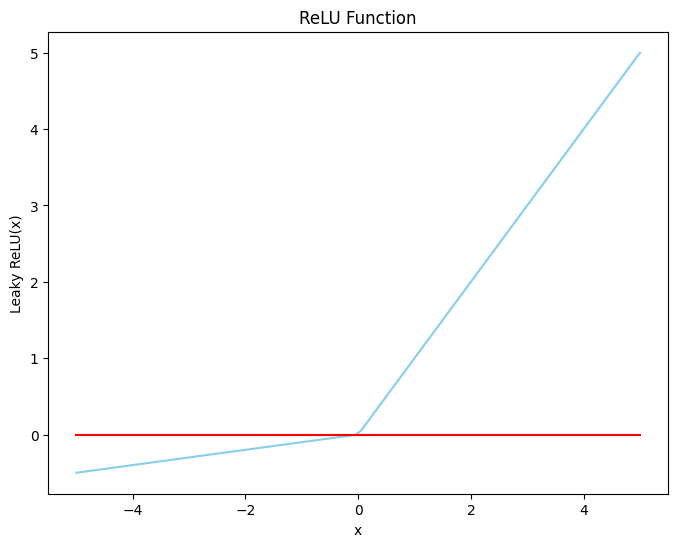

In [85]:
# Plot the Leaky ReLU function
c = 0.1
x = np.linspace(-5, 5, 100)
leaky_relu_values = [max(c*i, i) for i in x] # ReLU Function

plt.figure(figsize=(8, 6))
plt.plot(x, leaky_relu_values, label='ReLU', color='skyblue')
plt.plot(x, 0*x, label='y=0', color='red')
plt.title('ReLU Function')
plt.xlabel('x')
plt.ylabel('Leaky ReLU(x)')

### Sigmoid

$$f(z) = \frac{1}{1 + exp(-z)}$$

Text(0, 0.5, 'Sigmoid(x)')

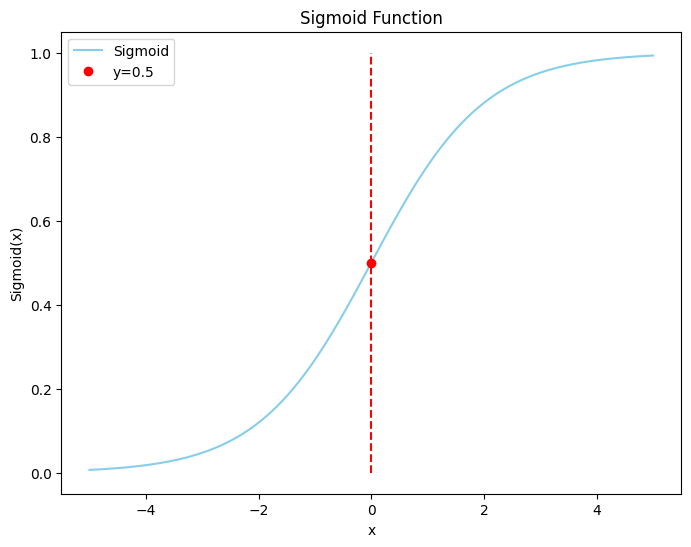

In [86]:
# Plot the Sigmoid function
x = np.linspace(-5, 5, 100)
sigmoid_values = 1/(1 + np.exp(-1*x)) # Sigmoid Function

plt.figure(figsize=(8, 6))
plt.plot(x, sigmoid_values, label='Sigmoid', color='skyblue')
plt.plot(0, 0.5, 'ro', label='y=0.5')
plt.vlines(0, 0, 1.0, linestyles='dashed', color='red')
plt.legend()
plt.title('Sigmoid Function')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')

### tanh

$$f(z) = tanh(z)$$

Text(0, 0.5, 'Sigmoid(x)')

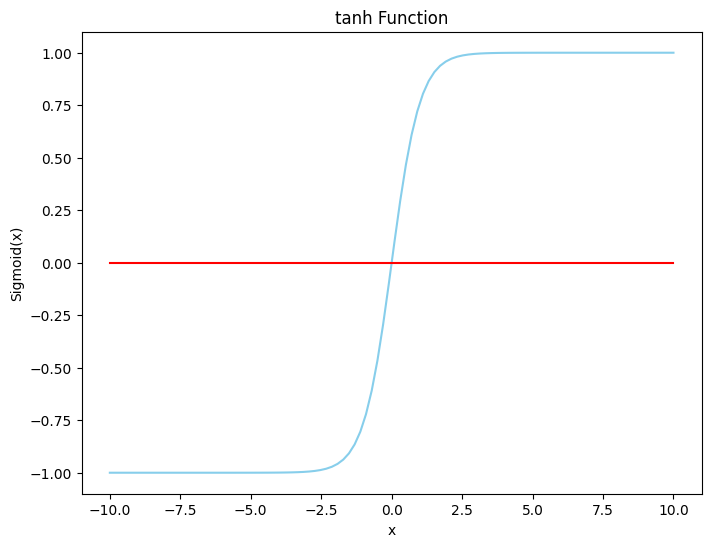

In [87]:
# Plot the tanh function
x = np.linspace(-10, 10, 100)
tanh_values = np.tanh(x) # tanh Function

plt.figure(figsize=(8, 6))
plt.plot(x, tanh_values, label='tanh', color='skyblue')
plt.plot(x, 0*x, label='y=0', color='red')
plt.title('tanh Function')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')